# Risk assessment — River flooding (Kazakhstan)

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[FLOODS](https://github.com/CLIMAAX/FLOODS) GitHub repository.

**This notebook must be run after the hazard notebook.**
It reads flood depth GeoTIFFs produced by `Hazard_assessment_FLOOD_RIVER_KZ.py`.

## Data Substitutions

| Original (CLIMAAX / Europe) | Kazakhstan Replacement | Reason |
|---|---|---|
| JRC CEMS-EFAS flood rasters (`Europe_RP{RP}_filled_depth.tif`) | CEMS-GLOFAS rasters from hazard notebook (`floodmap_GLOFAS_PresentScenario_*_RP{rp}.tif`) | EFAS is Europe-only; GLOFAS rasters were produced in the hazard notebook |
| EU NUTS/city-scale AOI | Almaty district, Astana city (coordinates) | EU admin units not applicable; district scale consistent with building-level analysis |
| `EPSG:3035` (EU Lambert Equal Area) for building area | `EPSG:32643` (UTM Zone 43N) **for area calculation only** | EPSG:3035 undefined outside Europe; UTM 43N minimises distortion at Astana's location |
| All other operations in EU projection | `EPSG:4326` (WGS84) | All plotting, masking, and reprojection use geographic CRS |
| Damage values in EUR, EU CPI | Damage values in USD — **illustrative example only** | See note below |
| JRC GHSL population data | **Unchanged** — already a global dataset | No substitution needed |
| OSM building data via `osmnx` | **Unchanged** — already global | No substitution needed |

**Damage values note:** The maximum damage values (USD/m²) used here are
illustrative example values loosely based on Huizinga et al. (2017)
*Global flood depth-damage functions* (JRC Technical Report).
They are CPI-adjusted from 2010 to 2022 using US CPI indices.
For a formal risk assessment, these should be replaced with
country-validated values from local engineering or insurance sources.
Results should be interpreted as relative indicators, not absolute damage estimates.

## Setup — libraries

In [1]:
import re
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from rasterio.mask import mask
from rasterio.transform import array_bounds
import rasterstats
import osmnx as ox
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Polygon, Point
import contextily as ctx
from pyproj import Transformer

warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("osmnx").setLevel(logging.WARNING)

## Setup — AOI and paths

The AOI is the **Almaty district of Astana city** — a central, densely built
district suitable for building-level flood damage analysis.
Swap the coordinates below for any other district-scale area.

In [2]:
Latitude1,  Longitude1 = 51.085, 71.438
Latitude2,  Longitude2 = 51.203, 71.785
saveName    = "AlmatyDistrict_Astana"
region_name = "Astana"   

ybuffer = 0.003
xbuffer = 0.005

SHAPEFILE_PATH = Path(
    r"C:\Users\dauzo\Models\crabook-kazakhstan\crabook"
    r"\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp"
)

workflow_dir   = Path(__file__).parent if "__file__" in dir() else Path(".")
HAZARD_DIR     = workflow_dir / "results" / region_name / "data"
results_dir    = workflow_dir / "results" / region_name / "risk" / saveName
osm_dir        = results_dir / "OSM"
dmg_dir        = results_dir / "DamageBuildings"
pop_dir        = results_dir / "ExposedPopulation"
plot_dir       = results_dir / "plots"

for d in [results_dir, osm_dir, dmg_dir, pop_dir, plot_dir]:
    d.mkdir(parents=True, exist_ok=True)

return_periods = [10, 50, 100, 200, 500]
for rp in return_periods:
    p = HAZARD_DIR / f"floodmap_GLOFAS_PresentScenario_{region_name}_RP{rp}.tif"
    if not p.exists():
        raise FileNotFoundError(
            f"Hazard raster not found: {p}\n"
            "Run the hazard notebook first."
        )
print("All hazard rasters found.")

outlineGeometry = gpd.GeoSeries(
    [Polygon([
        (Longitude1, Latitude1), (Longitude2, Latitude1),
        (Longitude2, Latitude2), (Longitude1, Latitude2),
    ])],
    crs="EPSG:4326",
)

kaz = gpd.read_file(SHAPEFILE_PATH)
print(f"AOI        : {saveName}")
print(f"Lon range  : [{Longitude1}, {Longitude2}]")
print(f"Lat range  : [{Latitude1}, {Latitude2}]")

All hazard rasters found.
AOI        : AlmatyDistrict_Astana
Lon range  : [71.438, 71.785]
Lat range  : [51.085, 51.203]


## Setup — figure options

In [3]:
ImageReturnPeriod = [10, 100, 500]   
for v in ImageReturnPeriod:
    if v not in return_periods:
        raise ValueError(f"{v} in ImageReturnPeriod is not in return_periods")

imageSaveFlag       = True
showOutlineFlag     = True
outlineLabelFlag    = True
outlineColour       = "limegreen"
outlineStyle        = "-"
outlineThickness    = 2
outlineFace         = "none"
outlineAlpha        = 1
outlineLabel        = f"{saveName} outline"
outlineLabelSize    = 8
outlineLabelPos     = "upper left"
customMaxDepthLegend = -1   

minDepthExposed    = 0.0   
minDepthDisplaced  = 1.0   

Depths = ["Mean"]

# Colormaps
cmap_h2o = LinearSegmentedColormap.from_list("h2o", ["blue", "red"],   N=256)
cmap_cls = LinearSegmentedColormap.from_list("cls", ["orange", "purple", "blue", "red"], N=256)
cmap_pop = LinearSegmentedColormap.from_list("pop", ["orange", "red", "fuchsia"], N=256)
cmap_dmg = LinearSegmentedColormap.from_list("dmg", ["blue", "red", "fuchsia"], N=256)

## Setup — population year

In [4]:
PopYear = 2020   
if not (isinstance(PopYear, int) and 1975 <= PopYear <= 2030 and PopYear % 5 == 0):
    raise ValueError("PopYear must be an integer between 1975 and 2030 and a multiple of 5.")

---
## Part 1 — Depth-damage functions

Damage functions are unchanged from the original CLIMAAX workflow —
polynomial fits to the JRC depth-damage curves (Huizinga et al. 2017).

**Maximum damage values** are illustrative example values in USD (2010 prices)
loosely based on Huizinga et al. (2017) Table 9 (Europe/Central Asia region).
Adjusted to 2022 USD using US CPI (2010: 218.1 → 2022: 296.3).
These are NOT validated Kazakhstan-specific estimates and must be replaced
with local data for a formal risk assessment.

In [5]:
CPI2010_US  = 100    
CPI2022_US  = 312.53    
CPI_Frac    = CPI2022_US / CPI2010_US

MaxDmgRES = np.array([290, 145]) * CPI_Frac   
MaxDmgCOM = np.array([315, 315]) * CPI_Frac   
MaxDmgIND = np.array([214, 321]) * CPI_Frac   
MaxDmgAGR = np.array([0.20, 0.40]) * CPI_Frac 
MaxDmgUNI = (MaxDmgRES + MaxDmgCOM + MaxDmgIND) / 3   

DamageClasses = ["Residential", "Commercial", "Industrial", "Universal"]


def DamageFunction(wd1, coefs, wd_range=(0, 6)):
    """Polynomial depth-damage function (JRC methodology, unchanged)."""
    wd = np.clip(wd1, *wd_range)
    y  = (coefs[0] * wd**5 + coefs[1] * wd**4 + coefs[2] * wd**3
          + coefs[3] * wd**2 + coefs[4] * wd + coefs[5])
    return np.clip(y, 0, 1)


coefs_UNI = [0.0,       0.0,        0.0,        -0.02787,  0.3334,  0.0]
coefs_RES = [0.0005869, -0.01077,   0.07497,    -0.2602,   0.5959,  0.0]
coefs_COM = [0.0,       0.0,        -0.0009149, -0.02021,  0.3216,  0.0]
coefs_IND = [0.0,       0.0,        -0.001202,  -0.01225,  0.2852,  0.0]
coefs_TRS = [0.0,       -0.00938,   0.07734,    -0.2906,   0.7625,  0.0]
coefs_AGR = [0.0,       -0.004601,  0.06114,    -0.3061,   0.7773,  0.0]

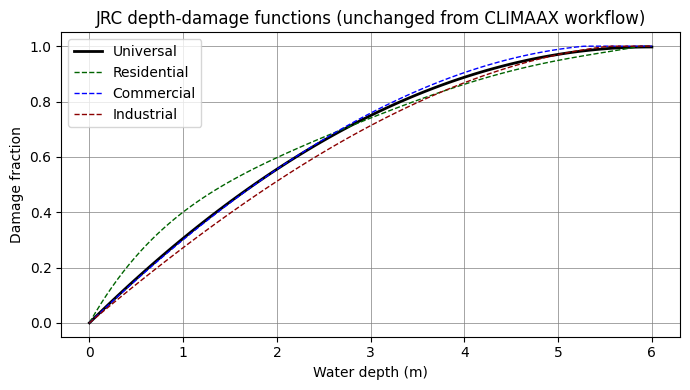

In [6]:
wd_vals = np.linspace(0, 6, 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wd_vals, DamageFunction(wd_vals, coefs_UNI), color="black",    lw=2,  label="Universal")
ax.plot(wd_vals, DamageFunction(wd_vals, coefs_RES), color="darkgreen", lw=1, ls="--", label="Residential")
ax.plot(wd_vals, DamageFunction(wd_vals, coefs_COM), color="blue",      lw=1, ls="--", label="Commercial")
ax.plot(wd_vals, DamageFunction(wd_vals, coefs_IND), color="darkred",   lw=1, ls="--", label="Industrial")
ax.grid(color="grey", ls="-", lw=0.5)
ax.set_xlabel("Water depth (m)")
ax.set_ylabel("Damage fraction")
ax.set_title("JRC depth-damage functions (unchanged from CLIMAAX workflow)")
ax.legend()
plt.tight_layout()
if imageSaveFlag:
    fig.savefig(plot_dir / "DamageCurves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 2 — Load and preview flood hazard rasters

Reads the CEMS-GLOFAS GeoTIFFs produced by the hazard notebook.
All rasters are in EPSG:4326.

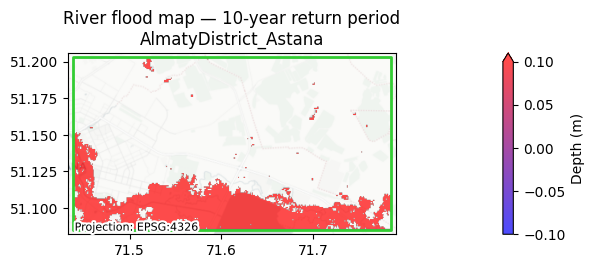

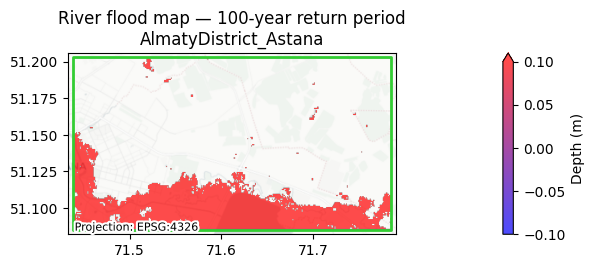

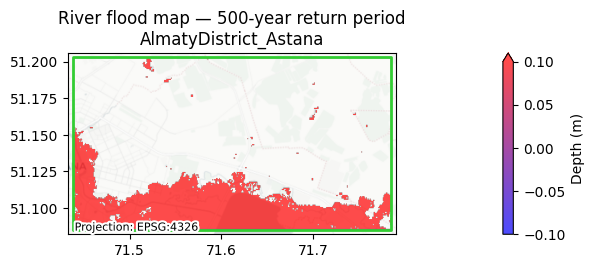

In [7]:
epsgRast = "EPSG:4326"

for rp in ImageReturnPeriod:
    rast_path = HAZARD_DIR / f"floodmap_GLOFAS_PresentScenario_{region_name}_RP{rp}.tif"
    with rasterio.open(rast_path) as src:
        clipped, out_transform = mask(src, outlineGeometry, crop=True)
        rDepths = np.ma.masked_where(
            (clipped[0] < 0) | (clipped[0] > 1000), clipped[0]
        )
        maxD = (rDepths.max() // 1 + 1) if customMaxDepthLegend == -1 else customMaxDepthLegend

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(
        rDepths, vmin=0, vmax=maxD, cmap=cmap_h2o,
        extent=(Longitude1, Longitude2, Latitude1, Latitude2),
        zorder=2, alpha=0.7,
    )
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    plt.colorbar(im, cax=cax, label="Depth (m)", extend="max")
    ax.set_title(f"River flood map — {rp}-year return period\n{saveName}")
    plt.text(0.02, 0.02, f"Projection: {epsgRast}", fontsize=8,
             path_effects=[pe.withStroke(linewidth=3, foreground="white")],
             transform=ax.transAxes)
    ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
    ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
    ctx.add_basemap(ax, crs=epsgRast, source=ctx.providers.CartoDB.Positron,
                   attribution=False)
    if showOutlineFlag:
        outlineGeometry.plot(ax=ax, edgecolor=outlineColour, linestyle=outlineStyle,
                             linewidth=outlineThickness, facecolor=outlineFace,
                             alpha=outlineAlpha, zorder=5)
    if imageSaveFlag:
        fig.savefig(plot_dir / f"floodmap_{rp}RP.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## Part 3 — Population data (GHSL)

Population data from the JRC Global Human Settlement Layer (GHSL).
This dataset is already global — **no substitution required**.
The original CLIMAAX tile-stitching logic is preserved unchanged.

In [8]:
import urllib.request
import socket
from zipfile import ZipFile

timeout    = 90
max_retries = 5
socket.setdefaulttimeout(timeout)

ghsl_dir = workflow_dir / "general_data" / "ghsl"
ghsl_dir.mkdir(parents=True, exist_ok=True)


def download_pop_rast(tile_id):
    """Download one GHSL population tile (unchanged from CLIMAAX workflow)."""
    url_base  = (
        f"https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/"
        f"GHS_POP_GLOBE_R2023A/GHS_POP_E{PopYear}_GLOBE_R2023A_4326_3ss/V1-0/tiles/"
    )
    tif_name  = f"GHS_POP_E{PopYear}_GLOBE_R2023A_4326_3ss_V1_0_{tile_id}.tif"
    zip_name  = tif_name.replace(".tif", ".zip")
    tif_path  = ghsl_dir / tif_name

    if tif_path.exists():
        print(f"  Cached: {tif_name}")
        return tif_path

    zip_path = ghsl_dir / zip_name
    for attempt in range(1, max_retries + 1):
        try:
            urllib.request.urlretrieve(url_base + zip_name, zip_path)
            break
        except Exception:
            if attempt == max_retries:
                raise
    with ZipFile(zip_path, "r") as z:
        z.extract(tif_name, ghsl_dir)
    zip_path.unlink()
    print(f"  Downloaded: {tif_name}")
    return tif_path


scheme_shp = ghsl_dir / "WGS84_tile_schema.shp"
if not scheme_shp.exists():
    scheme_zip = ghsl_dir / "GHSL_data_4326_shapefile.zip"
    urllib.request.urlretrieve(
        "https://ghsl.jrc.ec.europa.eu/download/GHSL_data_4326_shapefile.zip",
        scheme_zip,
    )
    with ZipFile(scheme_zip, "r") as z:
        z.extractall(ghsl_dir)
    scheme_zip.unlink()
    print("Downloaded GHSL tile scheme")
else:
    print("Cached: GHSL tile scheme")

gdf_scheme = gpd.read_file(scheme_shp)

tile_id_min = tile_id_max = None
for _, row in gdf_scheme.iterrows():
    l, t, r, b = row["left"], row["top"], row["right"], row["bottom"]
    if l <= Longitude1 <= r and b <= Latitude1 <= t:
        tile_id_min = row["tile_id"]
    if l <= Longitude2 <= r and b <= Latitude2 <= t:
        tile_id_max = row["tile_id"]
    if tile_id_min and tile_id_max:
        break

if tile_id_min == tile_id_max:
    rastPopulation = download_pop_rast(tile_id_max)
else:
    tM = tile_id_max.split("_"); Rmax, Cmax = tM[0][1:], tM[1][1:]
    tN = tile_id_min.split("_"); Rmin, Cmin = tN[0][1:], tN[1][1:]
    f1 = download_pop_rast(tile_id_min)
    f2 = download_pop_rast(tile_id_max)
    stitched = ghsl_dir / f"GHS_POP_E{PopYear}_{tile_id_min}_to_{tile_id_max}.tif"
    if not stitched.exists():
        import rasterio as rio
        with rio.open(f1) as s1, rio.open(f2) as s2:
            meta = s1.meta.copy()
            meta.update(width=s1.width + s2.width, height=max(s1.height, s2.height))
            with rio.open(stitched, "w", **meta) as dst:
                dst.write(s1.read(), window=rio.windows.Window(0, 0, s1.width, s1.height))
                for i in range(1, s2.count + 1):
                    dst.write(s2.read(i), i,
                              window=rio.windows.Window(s1.width, 0, s2.width, s2.height))
    rastPopulation = stitched

Cached: GHSL tile scheme
  Cached: GHS_POP_E2020_GLOBE_R2023A_4326_3ss_V1_0_R4_C26.tif


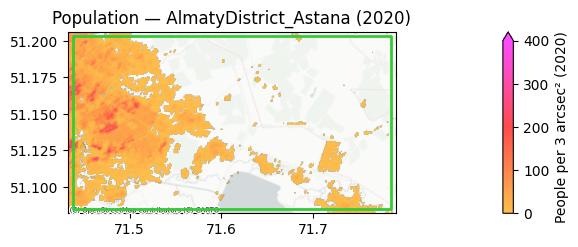

In [9]:
with rasterio.open(rastPopulation) as src:
    win = from_bounds(
        Longitude1 - xbuffer, Latitude1 - ybuffer,
        Longitude2 + xbuffer, Latitude2 + ybuffer,
        src.transform,
    )
    rPop = src.read(1, window=win)
    rPop = np.ma.masked_where(rPop < 0.1, rPop)
    pop_transform_preview = src.window_transform(win)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    rPop, vmin=0, vmax=max((rPop.max() // 100 + 1) * 100, 1),
    cmap=cmap_pop,
    extent=(Longitude1 - xbuffer, Longitude2 + xbuffer,
            Latitude1 - ybuffer,  Latitude2 + ybuffer),
    zorder=2, alpha=0.7,
)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im, cax=cax, label=f"People per 3 arcsec² ({PopYear})", extend="max")
ax.set_title(f"Population — {saveName} ({PopYear})")
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, attribution_size=5)
if showOutlineFlag:
    outlineGeometry.plot(ax=ax, edgecolor=outlineColour, ls=outlineStyle,
                         lw=outlineThickness, facecolor=outlineFace, zorder=5)
if imageSaveFlag:
    fig.savefig(plot_dir / f"population_{PopYear}.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 4 — OSM building data

OpenStreetMap building footprints via `osmnx`.
Dataset is already global — **no substitution required**.

In [10]:
shp_osm_raw    = osm_dir / f"{saveName}_OSM_Building_Unclassified.shp"
shp_osm_reclass = osm_dir / f"{saveName}_OSM_Building_Reclassified.shp"

if shp_osm_raw.exists():
    print(f"Cached: {shp_osm_raw.name}")
    gdfOSM = gpd.read_file(shp_osm_raw)
else:
    print("Downloading OSM building data...")
    tags   = {"building": True, "amenity": True}
    gdfOSM = ox.features_from_polygon(outlineGeometry.iloc[0], tags)
    gdfOSM = gdfOSM[gdfOSM.geom_type == "Polygon"]
    gdfOSM = gdfOSM.map(lambda x: str(x) if isinstance(x, list) else x)
    gdfOSM = gpd.clip(gdfOSM, outlineGeometry)
    gdfOSM.to_file(shp_osm_raw, driver="ESRI Shapefile", encoding="utf-8")
    print(f"Saved: {shp_osm_raw.name}")

print(f"Buildings in AOI: {len(gdfOSM)}")

Cached: AlmatyDistrict_Astana_OSM_Building_Unclassified.shp
Buildings in AOI: 21818


### Building classification

In [11]:
classResidential = [
    "hut", "apartments", "detached", "residential", "house", "barn",
    "garage", "carport", "semidetached_house", "shed", "bungalow",
    "roof", "terrace", "allotment_house",
]
classCommercial = [
    "commercial", "office", "retail", "kiosk", "supermarket", "warehouse",
    "garages", "hotel", "stadium", "grandstand", "sports_centre", "pavilion",
    "government", "school", "kindergarten", "university", "dormitory",
    "public", "service", "hospital", "civic", "terminal", "fire_station",
    "train_station", "boathouse", "toilets", "tech_cab", "tower", "portal",
    "greenhouse", "guardhouse", "construction", "funeral_hall",
]
classIndustrial    = ["industrial", "manufacture"]
classCultural      = ["church", "cathedral", "monastery", "chapel", "synagogue",
                      "shrine", "religious", "convent", "mosque", "temple"]
classAgricultural  = ["farm_auxiliary"]
classTransportation = ["bridge", "parking"]
classUniversal     = (["universal"] + classCultural
                      + classAgricultural + classTransportation)

criticalInfrastructureList = [
    "hospital", "fuel", "bank", "clinic", "pharmacy",
    "police", "prison", "fire_station", "train_station",
    "transformer_tower", "water_tower", "bridge",
]
critMarkersColours = {
    "hospital":     {"marker": "P", "color": "red"},
    "police":       {"marker": "s", "color": "blue"},
    "train_station":{"marker": "o", "color": "green"},
    "water_tower":  {"marker": "v", "color": "orange"},
    "bridge":       {"marker": "d", "color": "brown"},
    "fire_station": {"marker": "X", "color": "pink"},
    "fuel":         {"marker": "2", "color": "yellow"},
    "clinic":       {"marker": "P", "color": "salmon"},
    "pharmacy":     {"marker": "+", "color": "purple"},
}

In [12]:
gdfBuildings = gdfOSM[["building", "amenity", "geometry"]].copy()

bldgClasses = pd.DataFrame({"building": gdfBuildings["building"].unique()})
bldgClasses["bldgClass"] = None
bldgClasses.loc[bldgClasses["building"].isin(classResidential),  "bldgClass"] = "Residential"
bldgClasses.loc[bldgClasses["building"].isin(classCommercial),   "bldgClass"] = "Commercial"
bldgClasses.loc[bldgClasses["building"].isin(classIndustrial),   "bldgClass"] = "Industrial"
bldgClasses.loc[bldgClasses["building"].isin(classUniversal),    "bldgClass"] = "Universal"
bldgClasses["critInfrastructure"] = None
bldgClasses.loc[bldgClasses["building"].isin(criticalInfrastructureList), "critInfrastructure"] = True

amenityClasses = pd.DataFrame({"amenity": gdfBuildings["amenity"].unique()})
amenityClasses["critInfrastructure"] = None
amenityClasses.loc[amenityClasses["amenity"].isin(criticalInfrastructureList), "critInfrastructure"] = True

csv_classes = osm_dir / f"{saveName}_OSM_Building_Classes.csv"
csv_amenity = osm_dir / f"{saveName}_OSM_Amenity_Classes.csv"
bldgClasses.to_csv(csv_classes,  index=False)
amenityClasses.to_csv(csv_amenity, index=False)

print("Building classes (None = unclassified → will become Universal):")
print(bldgClasses.to_string())

Building classes (None = unclassified → will become Universal):
          building    bldgClass critInfrastructure
0             None         None               None
1              yes         None               None
2            house  Residential               None
3      residential  Residential               None
4             shed  Residential               None
5             roof  Residential               None
6       industrial   Industrial               None
7       apartments  Residential               None
8           retail   Commercial               None
9     construction   Commercial               None
10          garage  Residential               None
11   train_station   Commercial               True
12  transportation         None               None
13          school   Commercial               None
14       dormitory   Commercial               None
15       warehouse   Commercial               None
16        hospital   Commercial               True
17      grandstand

In [13]:
gdfOSMreclass = gdfOSM.merge(bldgClasses, on="building", how="left")
gdfOSMreclass["bldgClass"] = gdfOSMreclass["bldgClass"].fillna("Universal")
gdfOSMreclass.to_file(shp_osm_reclass, driver="ESRI Shapefile", encoding="utf-8")
print(f"Saved reclassified shapefile: {shp_osm_reclass.name}")

c:\Users\dauzo\miniconda3\envs\crabook-kz\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'critInfrastructure' to 'critInfras'
  ogr_write(


Saved reclassified shapefile: AlmatyDistrict_Astana_OSM_Building_Reclassified.shp


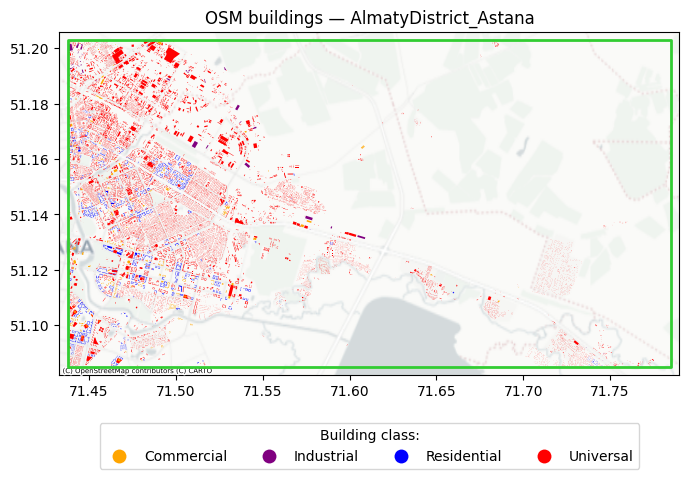

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
gdfOSMreclass.plot(column="bldgClass", ax=ax, legend=True, cmap=cmap_cls,
                   legend_kwds={"ncol": 4, "bbox_to_anchor": (0.5, -0.12),
                                "loc": "upper center", "title": "Building class:"})
ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
ax.set_title(f"OSM buildings — {saveName}")
ctx.add_basemap(ax, crs=gdfOSMreclass.crs, source=ctx.providers.CartoDB.Positron,
                attribution_size=5)
if showOutlineFlag:
    outlineGeometry.plot(ax=ax, edgecolor=outlineColour, ls=outlineStyle,
                         lw=outlineThickness, facecolor=outlineFace, zorder=5)
if imageSaveFlag:
    fig.savefig(plot_dir / "OSM_buildings_classified.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 5 — Flood depths at building locations

For each return period, zonal statistics (mean/min/max depth) are computed
for each building footprint from the GLOFAS rasters.

**Area calculation substitution note:**
Building footprint areas are computed in `EPSG:32643` (UTM Zone 43N) to
obtain correct m² values. All other operations remain in `EPSG:4326`.


Computing building water depths  RP=10


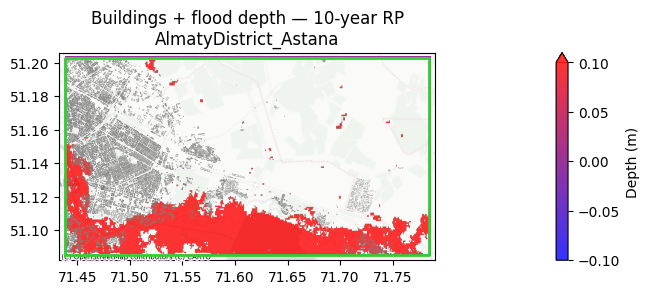


Computing building water depths  RP=50

Computing building water depths  RP=100


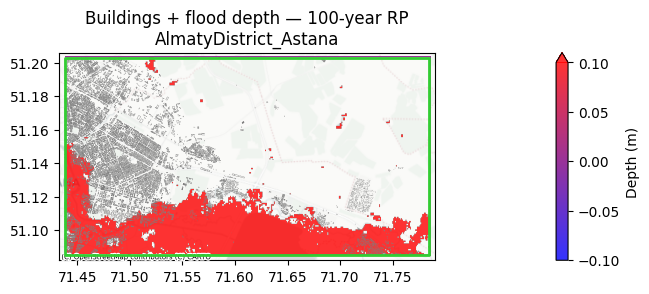


Computing building water depths  RP=200

Computing building water depths  RP=500


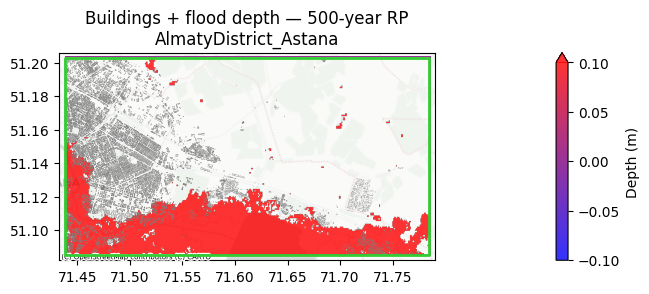


Done — building water depths computed for all return periods.


In [15]:
for rp in return_periods:
    print(f"\nComputing building water depths  RP={rp}")
    rast_path = HAZARD_DIR / f"floodmap_GLOFAS_PresentScenario_{region_name}_RP{rp}.tif"

    gdfDamage = gdfOSMreclass[["building", "bldgClass", "geometry"]].copy()

    gdfDamage["Area_m2"] = gdfDamage.to_crs("EPSG:32643").geometry.area

    with rasterio.open(rast_path) as src:
        clipped, out_transform = mask(src, outlineGeometry, crop=True)
        rDepths = clipped[0].astype(float)
        rDepths = np.ma.masked_where((rDepths < 0) | (rDepths > 1000), rDepths)
        nodata  = src.nodata

    result = rasterstats.zonal_stats(
        gdfDamage,
        rDepths,
        nodata=nodata if nodata is not None else -9999,
        affine=out_transform,
        stats=["mean", "min", "max"],
        all_touched=True,
    )
    gdfDamage["MeanDepth"] = [e["mean"] for e in result]
    gdfDamage["MinDepth"]  = [e["min"]  for e in result]
    gdfDamage["MaxDepth"]  = [e["max"]  for e in result]

    shp_depths = dmg_dir / f"{saveName}_Depths_Building_RP{rp}.shp"
    gdfDamage.to_file(shp_depths, driver="ESRI Shapefile")

    if rp in ImageReturnPeriod:
        height, width = rDepths.shape
        xMn, yMn, xMx, yMx = array_bounds(height, width, out_transform)
        maxD = (rDepths.max() // 1 + 1) if customMaxDepthLegend == -1 else customMaxDepthLegend

        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(rDepths, vmin=0, vmax=maxD, cmap=cmap_h2o,
                       extent=(xMn, xMx, yMn, yMx), zorder=1, alpha=0.8)
        gdfDamage.plot(ax=ax, edgecolor="grey", lw=0.25, facecolor="none", zorder=3)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="2%", pad=0.1)
        plt.colorbar(im, cax=cax, label="Depth (m)", extend="max")
        ax.set_title(f"Buildings + flood depth — {rp}-year RP\n{saveName}")
        ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
        ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
        ctx.add_basemap(ax, crs=epsgRast, source=ctx.providers.CartoDB.Positron,
                        attribution_size=5)
        if showOutlineFlag:
            outlineGeometry.plot(ax=ax, edgecolor=outlineColour, ls=outlineStyle,
                                 lw=outlineThickness, facecolor=outlineFace, zorder=5)
        if imageSaveFlag:
            fig.savefig(plot_dir / f"buildings_flooddepth_{rp}RP.png",
                        dpi=150, bbox_inches="tight")
        plt.show()

print("\nDone — building water depths computed for all return periods.")

---
## Part 6 — Economic damage to buildings

Damage = damage_fraction(depth) × area_m² × max_damage_per_m²
Output in millions of USD (illustrative — see damage values note above).

  Computing damage: RP=10, depth=Mean


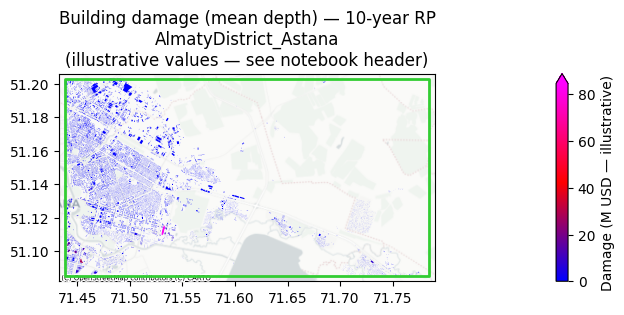

  Computing damage: RP=50, depth=Mean
  Computing damage: RP=100, depth=Mean


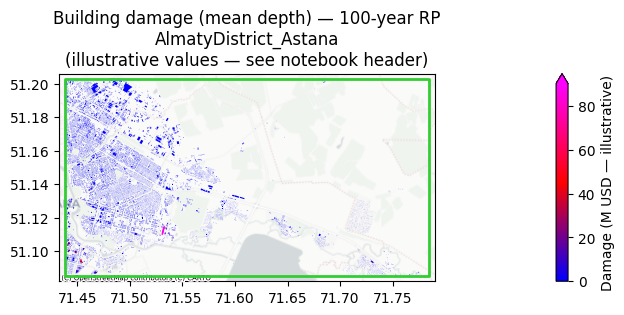

  Computing damage: RP=200, depth=Mean
  Computing damage: RP=500, depth=Mean


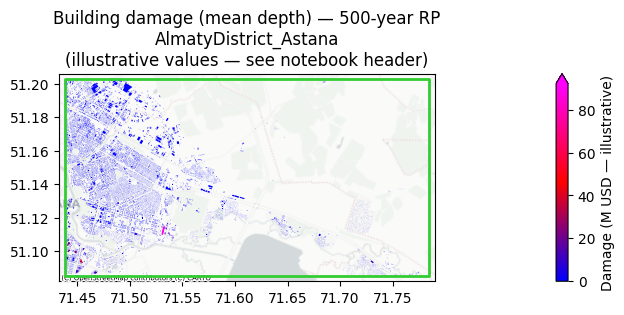

Done — building damage computed.


In [16]:
for rp in return_periods:
    shp_depths = dmg_dir / f"{saveName}_Depths_Building_RP{rp}.shp"
    gdfDamage  = gpd.read_file(shp_depths)

    for Depth in Depths:
        stat_col = {"Mean": "MeanDepth", "Max": "MaxDepth", "Min": "MinDepth"}[Depth]
        print(f"  Computing damage: RP={rp}, depth={Depth}")

        gdfDamage["TotDamage"] = 0.0

        for dmgClass in DamageClasses:
            bldgDmg = f"f{dmgClass[:3].upper()}{Depth.lower()}"
            dmgName = f"Dmg{bldgDmg[1:]}"

            coefs, MaxDmg = {
                "Residential": (coefs_RES, MaxDmgRES.sum()),
                "Commercial":  (coefs_COM, MaxDmgCOM.sum()),
                "Industrial":  (coefs_IND, MaxDmgIND.sum()),
                "Universal":   (coefs_UNI, MaxDmgUNI.sum()),
            }.get(dmgClass, (coefs_UNI, MaxDmgUNI.sum()))

            gdfDamage[bldgDmg] = DamageFunction(gdfDamage[stat_col].fillna(0), coefs)
            gdfDamage.loc[gdfDamage["bldgClass"] != dmgClass, bldgDmg] = 0.0
            gdfDamage[dmgName] = gdfDamage[bldgDmg] * gdfDamage["Area_m2"] * MaxDmg
            gdfDamage["TotDamage"] += gdfDamage[dmgName] / 1e6   # millions USD

        gdfDamage.to_file(shp_depths, driver="ESRI Shapefile")

        if rp in ImageReturnPeriod:
            fig, ax = plt.subplots(figsize=(8, 6))
            gdfDamage.plot(column="TotDamage", cmap=cmap_dmg, ax=ax, zorder=2)
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="2%", pad=0.1)
            plt.colorbar(ax.collections[0], cax=cax,
                         label="Damage (M USD — illustrative)", extend="max")
            ax.set_title(
                f"Building damage ({Depth.lower()} depth) — {rp}-year RP\n"
                f"{saveName}\n(illustrative values — see notebook header)"
            )
            ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
            ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
            ctx.add_basemap(ax, crs=gdfDamage.crs,
                            source=ctx.providers.CartoDB.Positron, attribution_size=5)
            if showOutlineFlag:
                outlineGeometry.plot(ax=ax, edgecolor=outlineColour, ls=outlineStyle,
                                     lw=outlineThickness, facecolor=outlineFace, zorder=5)
            if imageSaveFlag:
                fig.savefig(
                    plot_dir / f"building_damage_{Depth.lower()}_{rp}RP.png",
                    dpi=150, bbox_inches="tight",
                )
            plt.show()

print("Done — building damage computed.")

### Total damage and expected annual damage (EAD)

Mean EAD: 125.568 M USD (illustrative)


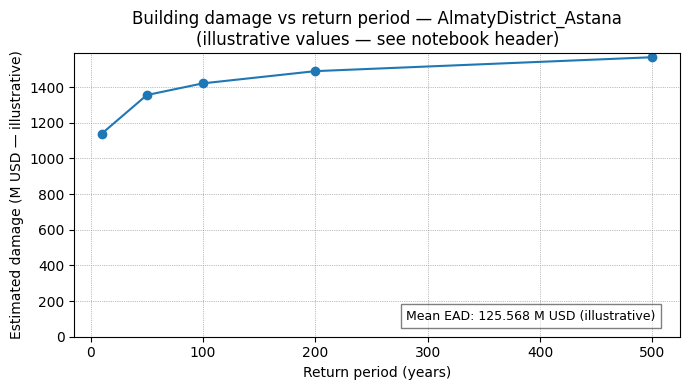

In [17]:
nDmg  = np.append(DamageClasses, "Total")
probRPs = 1 / np.array(return_periods)

for Depth in Depths:
    dfDMGs = pd.DataFrame(index=nDmg)
    dfDMGs.index.name = "Building Class"

    for rp in return_periods:
        shp_p  = dmg_dir / f"{saveName}_Depths_Building_RP{rp}.shp"
        gdf_rp = gpd.read_file(shp_p)
        vDmg   = []
        for dmgClass in DamageClasses:
            dmgCol = (f"DmgTRS{Depth.lower()}" if dmgClass == "Transportation"
                      else f"Dmg{dmgClass[:3].upper()}{Depth.lower()}")
            vDmg.append(gdf_rp[dmgCol].sum() if dmgCol in gdf_rp.columns else 0.0)
        vDmg.append(sum(vDmg))
        dfDMGs[f"{rp}-yr"] = vDmg

    dfDMGs.to_csv(dmg_dir / f"{saveName}_DamageTotal_{Depth}.csv")

    iTot = dfDMGs.index.get_loc("Total")
    EAD  = sum(
        (probRPs[i] - probRPs[i + 1])
        * (dfDMGs.iloc[iTot, i + 1] + dfDMGs.iloc[iTot, i]) / 2
        for i in range(len(return_periods) - 1)
    )
    ead_text = f"{Depth} EAD: {EAD / 1e6:.3f} M USD (illustrative)"
    print(ead_text)

    totDmg = dfDMGs.loc["Total"] / 1e6
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(return_periods, totDmg, marker="o")
    ax.set_ylim(0)
    ax.grid(ls=":", lw=0.5, color="gray")
    ax.set_xlabel("Return period (years)")
    ax.set_ylabel("Estimated damage (M USD — illustrative)")
    ax.set_title(
        f"Building damage vs return period — {saveName}\n"
        "(illustrative values — see notebook header)"
    )
    ax.text(0.96, 0.05, ead_text, transform=ax.transAxes, fontsize=9,
            va="bottom", ha="right",
            bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"))
    plt.tight_layout()
    if imageSaveFlag:
        fig.savefig(plot_dir / f"damage_graph_{Depth}.png", dpi=150, bbox_inches="tight")
    plt.show()

### Critical infrastructure exposure

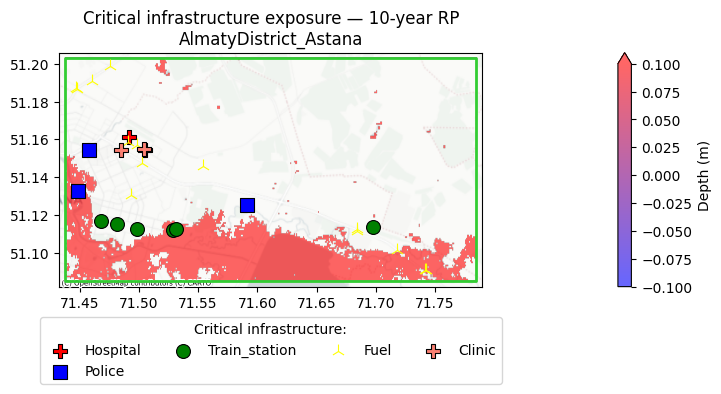

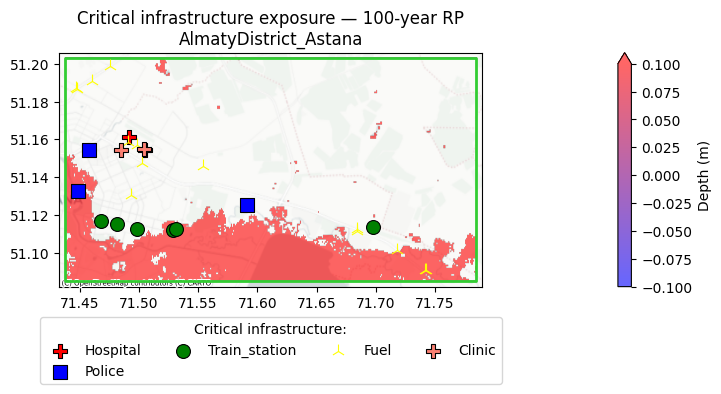

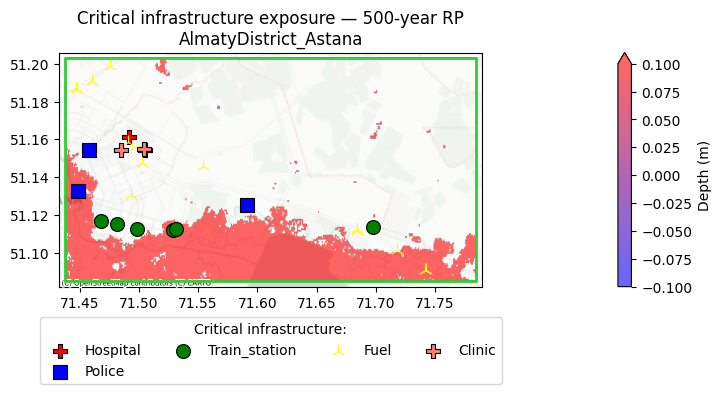

In [18]:
gdfOSMreclass["critInfrastructure"] = gdfOSMreclass["critInfrastructure"].infer_objects(copy=False)

for rp in ImageReturnPeriod:
    rast_path = HAZARD_DIR / f"floodmap_GLOFAS_PresentScenario_{region_name}_RP{rp}.tif"
    shp_depths = dmg_dir / f"{saveName}_Depths_Building_RP{rp}.shp"
    gdfDamage  = gpd.read_file(shp_depths)

    with rasterio.open(rast_path) as src:
        clipped, out_transform = mask(src, outlineGeometry, crop=True)
        rDepths = np.ma.masked_where(clipped[0] < 0, clipped[0])
        maxD = (rDepths.max() // 1 + 1) if customMaxDepthLegend == -1 else customMaxDepthLegend

    h, w = rDepths.shape
    xMn, yMn, xMx, yMx = array_bounds(h, w, out_transform)

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(rDepths, vmin=0, vmax=maxD, cmap=cmap_h2o,
                   extent=(xMn, xMx, yMn, yMx), zorder=1, alpha=0.6)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    plt.colorbar(im, cax=cax, label="Depth (m)", extend="max")
    ax.set_title(f"Critical infrastructure exposure — {rp}-year RP\n{saveName}")

    for btype, props in critMarkersColours.items():
        if btype in gdfOSMreclass["amenity"].unique():
            crit = gdfOSMreclass[gdfOSMreclass["amenity"] == btype]
        elif btype in gdfOSMreclass["building"].unique():
            crit = gdfOSMreclass[gdfOSMreclass["building"] == btype]
        else:
            continue
        centroids = crit.geometry.centroid
        ax.scatter(centroids.x, centroids.y,
                   color=props["color"], marker=props["marker"],
                   s=100, lw=0.8, edgecolors="k",
                   label=btype.capitalize(), zorder=6)

    ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
    ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
    ctx.add_basemap(ax, crs=epsgRast, source=ctx.providers.CartoDB.Positron,
                    attribution_size=5)
    if showOutlineFlag:
        outlineGeometry.plot(ax=ax, edgecolor=outlineColour, ls=outlineStyle,
                             lw=outlineThickness, facecolor=outlineFace, zorder=5)
    ax.legend(loc="upper center", ncol=4, bbox_to_anchor=(0.5, -0.1),
              title="Critical infrastructure:")
    if imageSaveFlag:
        fig.savefig(plot_dir / f"critical_infrastructure_{rp}RP.png",
                    dpi=150, bbox_inches="tight")
    plt.show()

---
## Part 7 — Population exposure and displacement

Population data (GHSL) is already global — methodology unchanged from CLIMAAX.

In [19]:
rastPop_zoom = ghsl_dir / f"GHS_POP_E{PopYear}_{saveName}.tif"

if not rastPop_zoom.exists():
    with rasterio.open(rastPopulation) as src:
        win = from_bounds(
            Longitude1 - xbuffer, Latitude1 - ybuffer,
            Longitude2 + xbuffer, Latitude2 + ybuffer,
            src.transform,
        )
        rPop = src.read(1, window=win)
        rPop = np.ma.masked_where(rPop < 0, rPop)
        with rasterio.open(
            rastPop_zoom, "w",
            driver="GTiff", height=rPop.shape[0], width=rPop.shape[1],
            count=1, dtype=rPop.dtype, crs=src.crs,
            transform=src.window_transform(win), nodata=src.nodata,
        ) as dst:
            dst.write(rPop, 1)
    print(f"Saved clipped population: {rastPop_zoom.name}")
else:
    print(f"Cached: {rastPop_zoom.name}")

Cached: GHS_POP_E2020_AlmatyDistrict_Astana.tif


  RP  10 — exposed: 34,228  displaced: 13,569


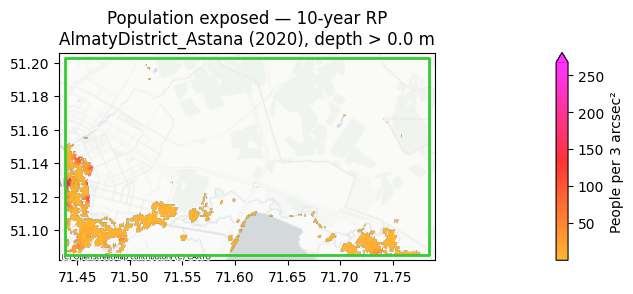

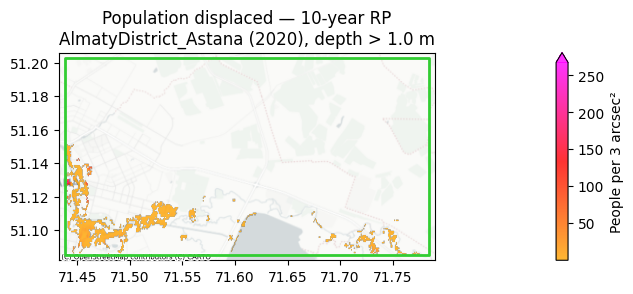

  RP  50 — exposed: 41,147  displaced: 20,043
  RP 100 — exposed: 43,065  displaced: 21,727


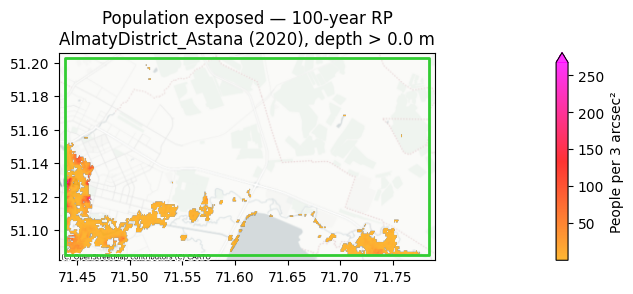

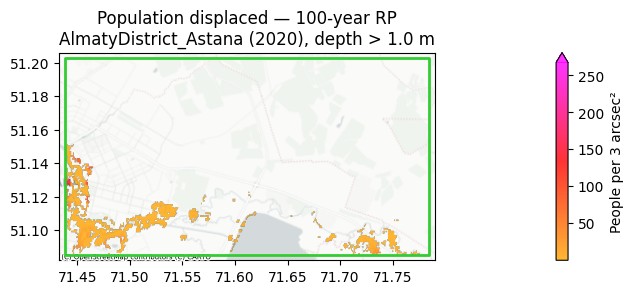

  RP 200 — exposed: 44,383  displaced: 23,624
  RP 500 — exposed: 45,822  displaced: 25,827


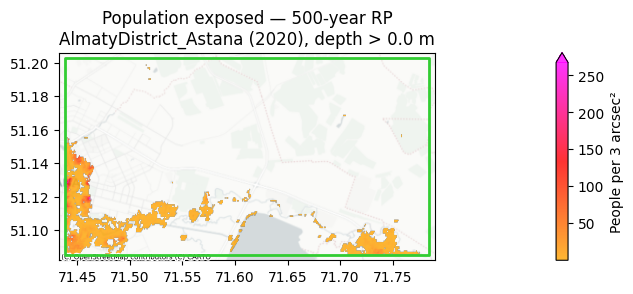

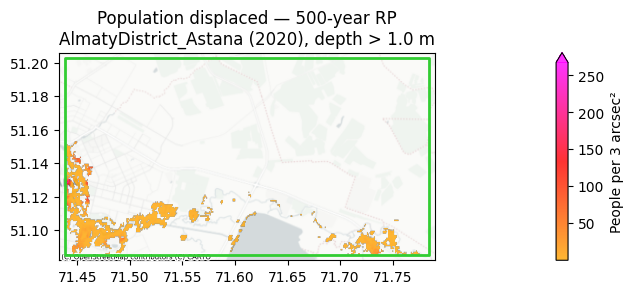

In [20]:
exposedPop   = []
displacedPop = []

for rp in return_periods:
    rast_path = HAZARD_DIR / f"floodmap_GLOFAS_PresentScenario_{region_name}_RP{rp}.tif"

    with rasterio.open(rast_path) as flood_src:
        clipped, out_tf = mask(flood_src, outlineGeometry, crop=True)
        rDepths_data = clipped[0].astype(float)

        with rasterio.open(rastPop_zoom) as pop_src:
            pop_data = pop_src.read(1)
            pop_tf, pop_w, pop_h = calculate_default_transform(
                pop_src.crs, flood_src.crs,
                pop_src.width, pop_src.height, *pop_src.bounds,
            )
            reproj_pop = np.zeros(rDepths_data.shape, dtype=pop_data.dtype)
            reproject(
                pop_data, reproj_pop,
                src_transform=pop_src.transform, src_crs=pop_src.crs,
                dst_transform=out_tf,            dst_crs=flood_src.crs,
                resampling=Resampling.nearest,
            )

        exposed   = np.where(rDepths_data > minDepthExposed,   1, 0) * reproj_pop
        displaced = np.where(rDepths_data > minDepthDisplaced, 1, 0) * reproj_pop

        exposedPop.append(int(np.sum(exposed)))
        displacedPop.append(int(np.sum(displaced)))
        print(f"  RP{rp:>4} — exposed: {exposedPop[-1]:,}  displaced: {displacedPop[-1]:,}")

        h, w = rDepths_data.shape
        xMn, yMn, xMx, yMx = array_bounds(h, w, out_tf)

        for label, arr, flag in [
            ("Exposed",   exposed,   rp in ImageReturnPeriod),
            ("Displaced", displaced, rp in ImageReturnPeriod),
        ]:
            if not flag:
                continue
            fig, ax = plt.subplots(figsize=(8, 6))
            im = ax.imshow(
                np.ma.masked_where(arr <= 0, arr),
                cmap=cmap_pop,
                extent=(xMn, xMx, yMn, yMx),
                zorder=2, alpha=0.8,
            )
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="2%", pad=0.1)
            plt.colorbar(im, cax=cax, label=f"People per 3 arcsec²", extend="max")
            thresh = minDepthExposed if label == "Exposed" else minDepthDisplaced
            ax.set_title(
                f"Population {label.lower()} — {rp}-year RP\n"
                f"{saveName} ({PopYear}), depth > {thresh} m"
            )
            ax.set_xlim(Longitude1 - xbuffer, Longitude2 + xbuffer)
            ax.set_ylim(Latitude1  - ybuffer, Latitude2  + ybuffer)
            ctx.add_basemap(ax, crs="EPSG:4326",
                            source=ctx.providers.CartoDB.Positron, attribution_size=5)
            if showOutlineFlag:
                outlineGeometry.plot(ax=ax, edgecolor=outlineColour, ls=outlineStyle,
                                     lw=outlineThickness, facecolor=outlineFace, zorder=5)
            if imageSaveFlag:
                fig.savefig(
                    plot_dir / f"pop_{label.lower()}_{rp}RP.png",
                    dpi=150, bbox_inches="tight",
                )
            plt.show()

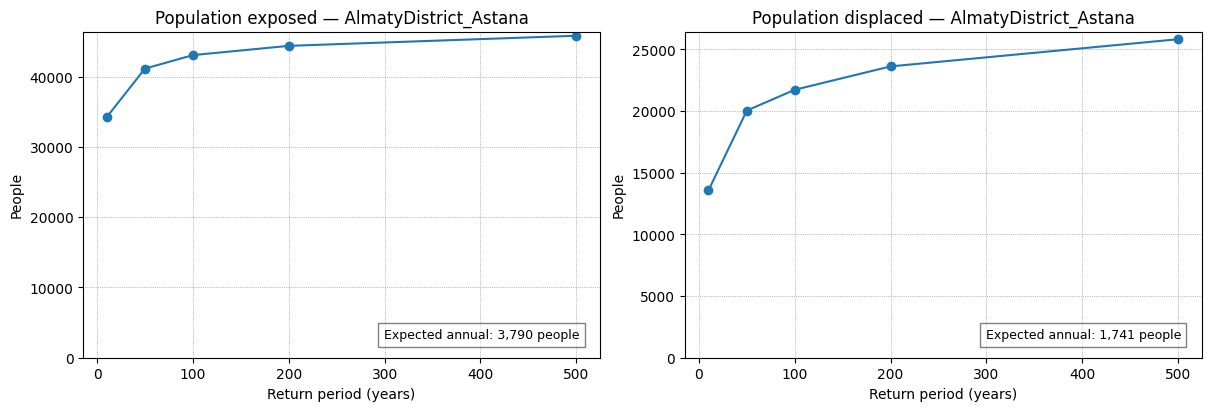

Expected annual population exposed  : 3,790
Expected annual population displaced: 1,741


In [21]:
EAEP = sum(
    (probRPs[i] - probRPs[i + 1]) * (exposedPop[i + 1] + exposedPop[i]) / 2
    for i in range(len(return_periods) - 1)
)
EADP = sum(
    (probRPs[i] - probRPs[i + 1]) * (displacedPop[i + 1] + displacedPop[i]) / 2
    for i in range(len(return_periods) - 1)
)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, vals, label, eav in [
    (axs[0], exposedPop,   "Exposed",   EAEP),
    (axs[1], displacedPop, "Displaced", EADP),
]:
    ax.plot(return_periods, vals, marker="o")
    ax.set_ylim(0)
    ax.grid(ls=":", lw=0.5, color="gray")
    ax.set_xlabel("Return period (years)")
    ax.set_ylabel("People")
    ax.set_title(f"Population {label.lower()} — {saveName}")
    ax.text(0.96, 0.05, f"Expected annual: {round(eav):,} people",
            transform=ax.transAxes, fontsize=9, va="bottom", ha="right",
            bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"))

if imageSaveFlag:
    fig.savefig(plot_dir / "population_graphs.png", dpi=150, bbox_inches="tight")
plt.show()

dfPOP = pd.DataFrame({
    "Return Period (yr)":   return_periods,
    "Exposed Population":   exposedPop,
    "Displaced Population": displacedPop,
})
dfPOP.to_csv(pop_dir / f"{saveName}_PopulationExposureDisplacement.csv", index=False)
print(f"Expected annual population exposed  : {round(EAEP):,}")
print(f"Expected annual population displaced: {round(EADP):,}")

---
## Conclusions

This risk workflow demonstrated:

- Reading CEMS-GLOFAS flood depth rasters produced by the hazard notebook
  and computing building-level flood depths via zonal statistics.
- Estimating economic damage to buildings using JRC depth-damage functions
  with illustrative USD damage values (see header note).
- Mapping critical infrastructure exposure for selected return periods.
- Quantifying exposed and displaced population using GHSL data,
  and computing expected annual exposure and displacement.

**Kazakhstan-specific notes:**
- The Almaly district AOI is used as a representative example.
  Change `Latitude1/2`, `Longitude1/2`, and `saveName` for other districts.
- Damage values are illustrative. Replace with validated local data
  (local construction costs, insurance data) for formal risk assessment.
- OSM building coverage in Astana is reasonably complete for major structures
  but may underrepresent informal or peri-urban buildings.
- GHSL population at 3 arc-seconds (~90 m) may place population over the
  Malaya Almatinka river channel, slightly inflating exposed population counts.